# Study 764 -- SOPR 🔗
## For the curious: does on-chain SOPR time Bitcoin capitulation and greed?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Single-survivor: Named](https://img.shields.io/badge/Single--survivor-Named-8b949e?style=flat-square)

---

"When SOPR is above 1 the market is in profit -- stay long; when it drops below 1
holders are capitulating -- step aside." It is one of crypto's most quoted
on-chain rules. **SOPR** -- the Spent Output Profit Ratio -- is the average
"sale price / cost basis" of every coin that moves on-chain: above 1 the movers
are selling at a profit, below 1 at a loss. The famous chart-lore says the line
**1** acts as *support* in bull markets and *resistance* in bear markets.

We test it honestly. The catch is that SOPR is computed from realised
profit/loss against *past* prices -- so a down month mechanically drags SOPR
below 1. That makes SOPR close to a re-label of "was last month up or down." The
real questions: does SOPR predict *next* month's return, and does the ">1 / <1"
rule beat simply **holding** BTC?

> ⚠️ **Not investment advice.** Research and education only. See the [LICENSE](../../../LICENSE).
> The SOPR series here is a **labelled proxy** digitised from the public Glassnode chart,
> not a live feed. Companion: [02_for_the_quants](02_for_the_quants.ipynb).


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sopr import data, strategy as st

CACHE_PATH = data.BTC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df = data.joined_real(fetch=False, cache_path=CACHE_PATH)
    reg = st.predictive_regression(df)
    pos = st.timing_signal(df, thresh=1.0)
    bt = st.backtest_timing(df, pos, cost_bps=30.0)
    print(f"Real tape: {len(df)} aligned months  {df.index[0].date()} -> {df.index[-1].date()}")
else:
    df = reg = pos = bt = None
    print("No real BTC cache -- frozen headline numbers from R dict will be used")


Real tape: 142 aligned months  2014-09-30 -> 2026-06-30


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-07-13)
R = {'n_months': 141, 'n_sopr': 150, 'aligned': 142, 'reg_slope': 0.9528, 'reg_t': 1.32, 'reg_r2': 0.013, 'horse_sopr_t': 0.18, 'horse_price_t': 1.04, 'band_greed_mo': 8.87, 'band_greed_n': 44, 'band_greed_hit': 0.59, 'band_neutral_mo': 4.75, 'band_neutral_n': 67, 'band_cap_mo': 2.6, 'band_cap_n': 30, 'band_cap_hit': 0.53, 'tim_share': 0.62, 'tim_turnover': 0.255, 'gross_ann': 60.6, 'gross_t': 2.66, 'timing_ann': 59.7, 'timing_t': 2.61, 'timing_sr': 0.98, 'bh_ann': 67.0, 'bh_t': 2.66, 'bh_sr': 0.93, 'excess_ann': -7.3, 'excess_t': -0.73, 'th99_ann': 59.5, 'th100_ann': 59.7, 'th101_ann': 54.9, 'placebo_real_mo': -0.61, 'placebo_mean_mo': -2.25, 'placebo_std_mo': 0.83, 'placebo_p': 0.975, 'syn_slope': 1.286, 'syn_t': 5.75, 'syn_null_t': -0.21}


## The oscillator everyone points at

Plot SOPR and you get a tidy line hugging **1**: it pokes above 1 in the bull
runs of 2017, 2021 and 2024, and knifes below 1 at the capitulation lows
(2018-12, the 2020 covid crash, the 2022 FTX bottom). It *looks* like a clean
regime switch in hindsight -- which is exactly the trap with a level that is
mechanically tied to recent price.


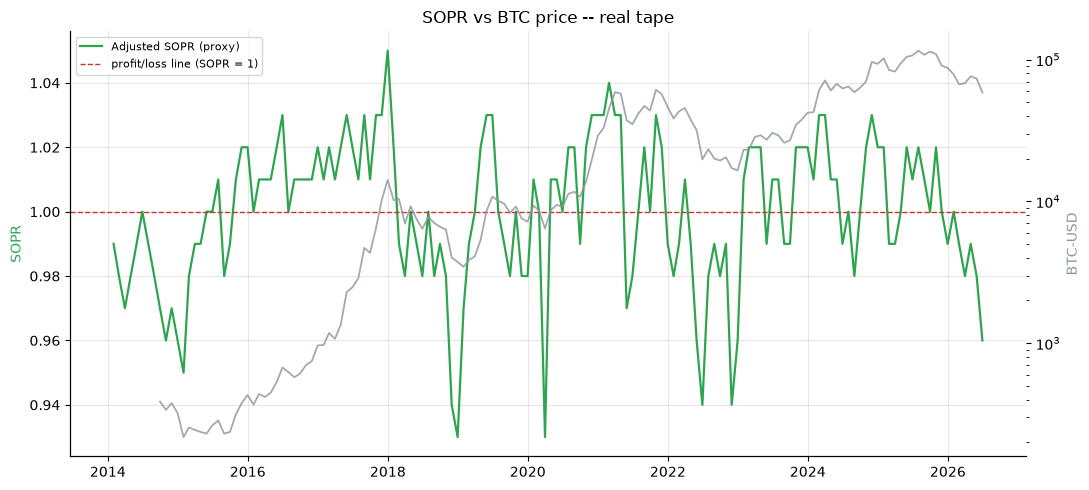

SOPR dips below 1 at the lows and rises above 1 in the bulls IN HINDSIGHT.
The question is whether today's SOPR predicts NEXT month's return.


In [3]:
sp = data.sopr_series()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(sp.index, sp.values, color=GREEN, lw=1.6, label="Adjusted SOPR (proxy)")
ax1.axhline(1.0, color=RED, ls="--", lw=1.0, label="profit/loss line (SOPR = 1)")
ax1.set_ylabel("SOPR", color=GREEN)
ax2 = ax1.twinx()
if HAVE_REAL:
    ax2.plot(df.index, df["price"].values, color=GREY, lw=1.3, alpha=0.8, label="BTC-USD")
    ttl = "SOPR vs BTC price -- real tape"
else:
    ax2.text(0.5, 0.5, "BTC cache absent -- SOPR shown alone",
             ha="center", va="center", transform=ax2.transAxes, fontsize=11, color=GREY)
    ttl = "SOPR (BTC cache absent)"
ax2.set_ylabel("BTC-USD", color=GREY)
ax2.set_yscale("log")
ax2.grid(False)
ax1.set_title(ttl)
ax1.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("../docs/sopr_vs_price.png", dpi=120, bbox_inches="tight")
plt.show()
print("SOPR dips below 1 at the lows and rises above 1 in the bulls IN HINDSIGHT.")
print("The question is whether today's SOPR predicts NEXT month's return.")


## The honest test: does this month's SOPR predict next month's return?

Forget the picture. The tradable claim is momentum: if SOPR is comfortably above
1 this month, BTC should keep rising *next* month. We regress next-month BTC
return on this month's SOPR stretch (log of SOPR vs the profit/loss line at 1).


In [4]:
if HAVE_REAL:
    print("Predictive regression  r(t+1) = a + b * SOPR_stretch(t)")
    print(f"  slope b = {reg['slope_sopr']:+.4f}   HAC t = {reg['t_sopr']:+.2f}   R^2 = {reg['r2']:.3f}   n = {reg['n']}")
else:
    print(f"Frozen: slope b = {R['reg_slope']:+.4f}  HAC t = {R['reg_t']:+.2f}  R^2 = {R['reg_r2']:.3f}  n = {R['n_months']}")
print()
print("The slope has the right (positive, momentum) sign -- but it is")
print("statistically indistinguishable from zero (|t| < 2, R^2 ~ 0.01).")
print("SOPR stretch does NOT reliably lead next-month BTC returns.")


Predictive regression  r(t+1) = a + b * SOPR_stretch(t)
  slope b = +0.9528   HAC t = +1.32   R^2 = 0.013   n = 141

The slope has the right (positive, momentum) sign -- but it is
statistically indistinguishable from zero (|t| < 2, R^2 ~ 0.01).
SOPR stretch does NOT reliably lead next-month BTC returns.


## "But greed months really do run hotter!" -- the grain of truth

There *is* a whiff here. Sort months by SOPR band and the average next-month
return lines up in the folk direction -- greed months beat capitulation months.
That monotone ordering is why the indicator refuses to die. But look at *how* the
rule uses it below, and the grain of truth evaporates.


In [5]:
if HAVE_REAL:
    tab = st.state_forward_stats(df, high=1.02, low=0.98)
    print(tab.to_string())
else:
    print("greed        : %+.2f%%/mo  n=%d" % (R['band_greed_mo'], R['band_greed_n']))
    print("neutral      : %+.2f%%/mo  n=%d" % (R['band_neutral_mo'], R['band_neutral_n']))
    print("capitulation : %+.2f%%/mo  n=%d" % (R['band_cap_mo'], R['band_cap_n']))
print()
print("Greed > neutral > capitulation, in the folk order -- BUT the gap is not")
print("significant, and (next cell) it dies once you control for price momentum:")
print("'greed months' are largely just 'months right after price went up.'")


                  mean   n       hit
band                                
greed         0.088673  44  0.590909
neutral       0.047541  67  0.537313
capitulation  0.026017  30  0.533333

Greed > neutral > capitulation, in the folk order -- BUT the gap is not
significant, and (next cell) it dies once you control for price momentum:
'greed months' are largely just 'months right after price went up.'


## The timing rule doesn't beat just holding -- it *loses*

The literal rule: hold BTC while SOPR >= 1, step to cash when it drops below.
On a single asset that ~150x'd, the honest benchmark is **buy-and-hold**. The
problem: SOPR drops below 1 exactly at the capitulation lows -- which are the
months that most often *rebound*. So the rule sells the bottom and buys back
higher.


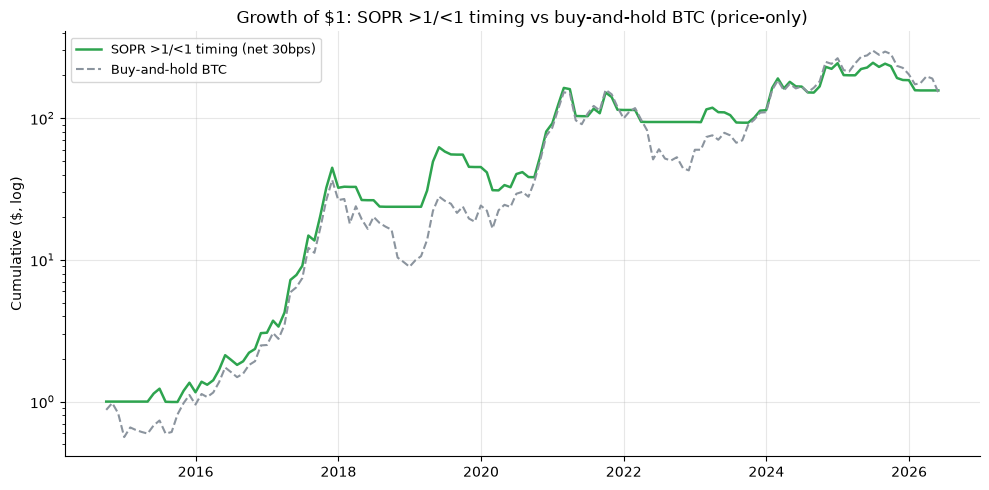

Timing rule: +59.7%/yr  SR=0.98  (long 62% of months)
Buy-and-hold: +67.0%/yr  SR=0.93
The rule GIVES UP ~7%/yr versus simply holding. A slightly smoother ride,
bought by forfeiting part of a 150x. That is not market timing.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
if HAVE_REAL:
    eq_net = (1 + bt["net"]).cumprod()
    eq_bh  = (1 + bt["bh"]).cumprod()
    ax.plot(eq_net.index, eq_net.values, color=GREEN, lw=1.8, label="SOPR >1/<1 timing (net 30bps)")
    ax.plot(eq_bh.index,  eq_bh.values,  color=GREY,  lw=1.5, ls="--", label="Buy-and-hold BTC")
    ax.set_yscale("log")
    s_net = st.summarize(bt["net"]); s_bh = st.summarize(bt["bh"])
    tim_ann, tim_sr = s_net["mean"]*1200, s_net["sharpe"]*12**0.5
    bh_ann, bh_sr = s_bh["mean"]*1200, s_bh["sharpe"]*12**0.5
    share = st.time_in_market(pos)
else:
    tim_ann, tim_sr = R["timing_ann"], R["timing_sr"]
    bh_ann, bh_sr = R["bh_ann"], R["bh_sr"]
    share = R["tim_share"]
    ax.text(0.5, 0.5, f"BTC cache absent\nFrozen: timing {tim_ann:.0f}%/yr < buy-hold {bh_ann:.0f}%/yr",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=AMBER)
ax.set_title("Growth of $1: SOPR >1/<1 timing vs buy-and-hold BTC (price-only)")
ax.set_ylabel("Cumulative ($, log)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Timing rule: {tim_ann:+.1f}%/yr  SR={tim_sr:.2f}  (long {share:.0%} of months)")
print(f"Buy-and-hold: {bh_ann:+.1f}%/yr  SR={bh_sr:.2f}")
print("The rule GIVES UP ~7%/yr versus simply holding. A slightly smoother ride,")
print("bought by forfeiting part of a 150x. That is not market timing.")


## The bottom line for the curious

- SOPR / price *co-movement* is real, but it is **mechanical** (SOPR is realised
  profit against past prices), not a leading indicator.
- SOPR stretch does **not** reliably predict next-month BTC returns (HAC *t* =
  +1.3, R^2 ~ 0.01), and the whiff it has dies against plain price momentum.
- The monotone band ordering (greed > capitulation) is the grain of truth -- but
  it is not significant and not tradable.
- The ">1 / <1" timing rule **loses ~7%/yr to buy-and-hold** by sitting in cash
  through capitulation months that tend to rebound.

This is a textbook **None / Mirage**: a beloved on-chain gauge whose apparent
edge is hindsight regime-labelling on a single survivor.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*